In [2]:
import pandas as  pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn import datasets

In [4]:
##Import iris datasets
iris = datasets.load_iris()
iris_data = pd.DataFrame(iris.data)
iris_data.columns = iris.feature_names
iris_data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [5]:
##Standardiztion
from sklearn.preprocessing import StandardScaler

In [6]:
scaler = StandardScaler()

In [7]:
x_scaled = scaler.fit_transform(iris_data)
x_scaled
x_scaled.shape

(150, 4)

In [8]:
##Apply the pca
from sklearn.decomposition import PCA

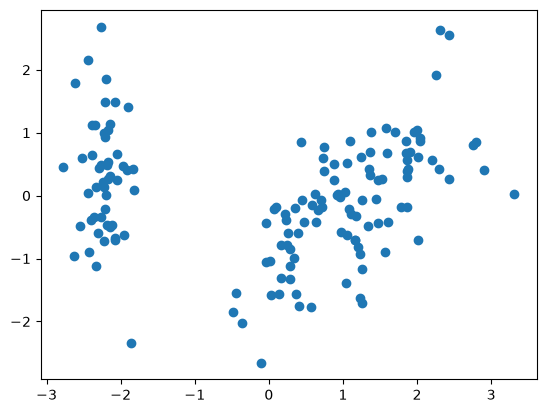

In [10]:
pca = PCA(n_components = 2)
pca_scaled = pca.fit_transform(x_scaled)
plt.scatter(pca_scaled[:,0],pca_scaled[:,1])

In [11]:
##Agglomerative clustering
## To construct a dendogram
import scipy.cluster.hierarchy as sc

Text(0.5, 1.0, 'Dendogram')

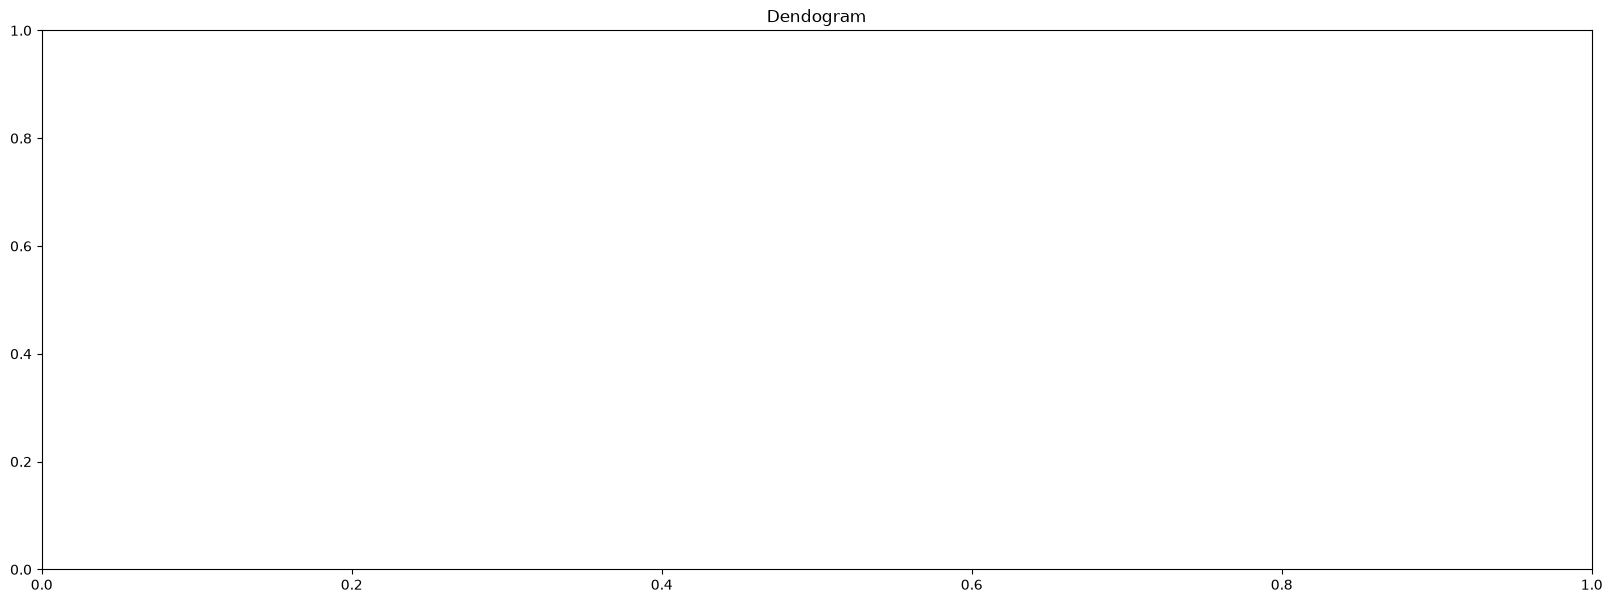

In [12]:
## Plot the dendogram
plt.figure(figsize=(20,7))
plt.title("Dendogram")

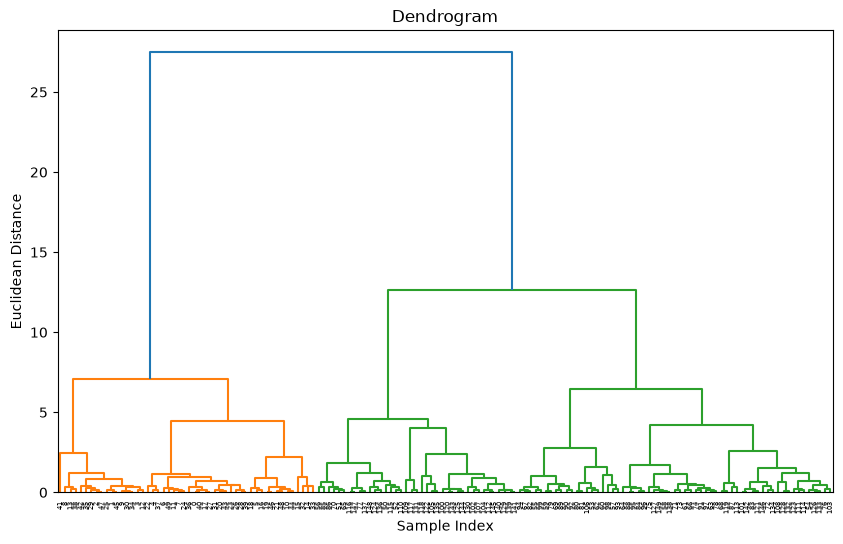

In [15]:

from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Create linkage matrix
linked = linkage(pca_scaled, method='ward')

# Create dendrogram
plt.figure(figsize=(10, 6))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Euclidean Distance")
plt.show()

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


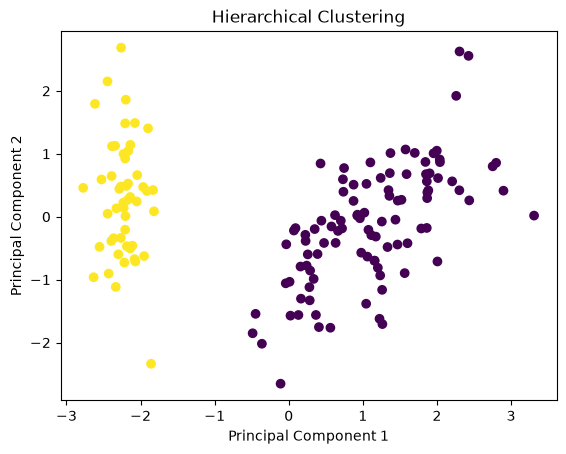

In [23]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

cluster = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward'
)

cluster.fit(pca_scaled)

print(cluster.labels_)

plt.scatter(
    pca_scaled[:, 0],
    pca_scaled[:, 1],
    c=cluster.labels_
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering")
plt.show()




In [24]:
##Silhouette score
from sklearn.metrics import silhouette_score

In [25]:
silhouette_coefficients = []

In [30]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

silhouette_coefficients = []

for k in range(2, 11):
    agglo = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        linkage='ward'
    )

    agglo.fit(x_scaled)

    score = silhouette_score(
        x_scaled,
        agglo.labels_
    )

    silhouette_coefficients.append(score)

print(silhouette_coefficients)

[0.5770346019475988, 0.446689041028591, 0.40063631598559735, 0.33058726295230545, 0.31485480100512825, 0.31696983029912795, 0.31094652900725794, 0.31143422475471655, 0.3161120375980681]


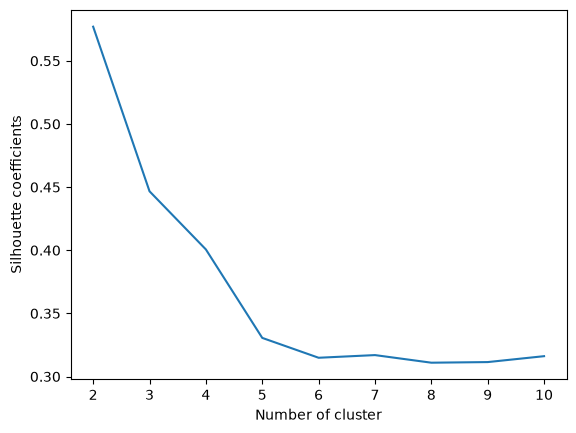

In [31]:
##Plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of cluster")
plt.ylabel("Silhouette coefficients")
plt.show()